# Classificação de Pinguins - Integração S3 (MinIO)

In [1]:
import pandas as pd
import boto3
import io
import os
from botocore.client import Config

# Desabilitar warnings gerais para leitura limpa
import warnings
warnings.filterwarnings('ignore')

# Configuração de conexão do MinIO (S3)
MINIO_ENDPOINT = os.getenv('AWS_S3_ENDPOINT', 'http://minio:9000')
MINIO_ACCESS_KEY = os.getenv('AWS_ACCESS_KEY_ID', 'minioadmin')
MINIO_SECRET_KEY = os.getenv('AWS_SECRET_ACCESS_KEY', 'minioadmin')
BUCKET_NAME = 'landing-zone'
FILE_NAME = 'penguins.csv'

print("Configurando cliente S3/MinIO...")
s3_client = boto3.client(
    's3',
    endpoint_url=MINIO_ENDPOINT,
    aws_access_key_id=MINIO_ACCESS_KEY,
    aws_secret_access_key=MINIO_SECRET_KEY,
    config=Config(signature_version='s3v4'),
    region_name='us-east-1'
)

Configurando cliente S3/MinIO...


## 1. Conexão e Ingestão de Dados do S3 (`landing-zone`)

In [2]:
# Baixar o dataset do Bucket landing-zone
try:
    print(f"Buscando arquivo '{FILE_NAME}' no bucket '{BUCKET_NAME}'...")
    response = s3_client.get_object(Bucket=BUCKET_NAME, Key=FILE_NAME)
    csv_content = response['Body'].read()
    
    # Carregando no Pandas
    df = pd.read_csv(io.BytesIO(csv_content))
    print("Dataset carregado com sucesso pelo MinIO!")
    df.head()
except Exception as e:
    print(f"Erro ao ler arquivo do S3/MinIO: {e}")

Buscando arquivo 'penguins.csv' no bucket 'landing-zone'...
Dataset carregado com sucesso pelo MinIO!


## 2. Limpeza de Dados Modernizada

In [3]:
# Limpeza dos dados replicada do ambiente original
print("Preenchendo valores ausentes (Imputação da Mediana)...")
md1 = df['bico_comp_mm'].median()
md2 = df['bico_largura_mm'].median()
md3 = df['nadadeira_comp_mm'].median()
md4 = df['masso_corporal_g'].median()

# O atributo massa_corporal_kg pode não existir, vamos criar um robust fallback
try:
    md5 = df['massa_corporal_kg'].median()
    df['massa_corporal_kg'].fillna(md5, inplace=True)
except KeyError:
    pass

df['bico_comp_mm'].fillna(md1, inplace=True)
df['bico_largura_mm'].fillna(md2, inplace=True)
df['nadadeira_comp_mm'].fillna(md3, inplace=True)
df['masso_corporal_g'].fillna(md4, inplace=True)

df.isna().sum()

Preenchendo valores ausentes (Imputação da Mediana)...


especies              0
ilha                  0
bico_comp_mm          0
bico_largura_mm       0
nadadeira_comp_mm     0
masso_corporal_g      0
massa_corporal_kg     0
sexo                 11
ano                   0
dtype: int64

## 3. Visualização

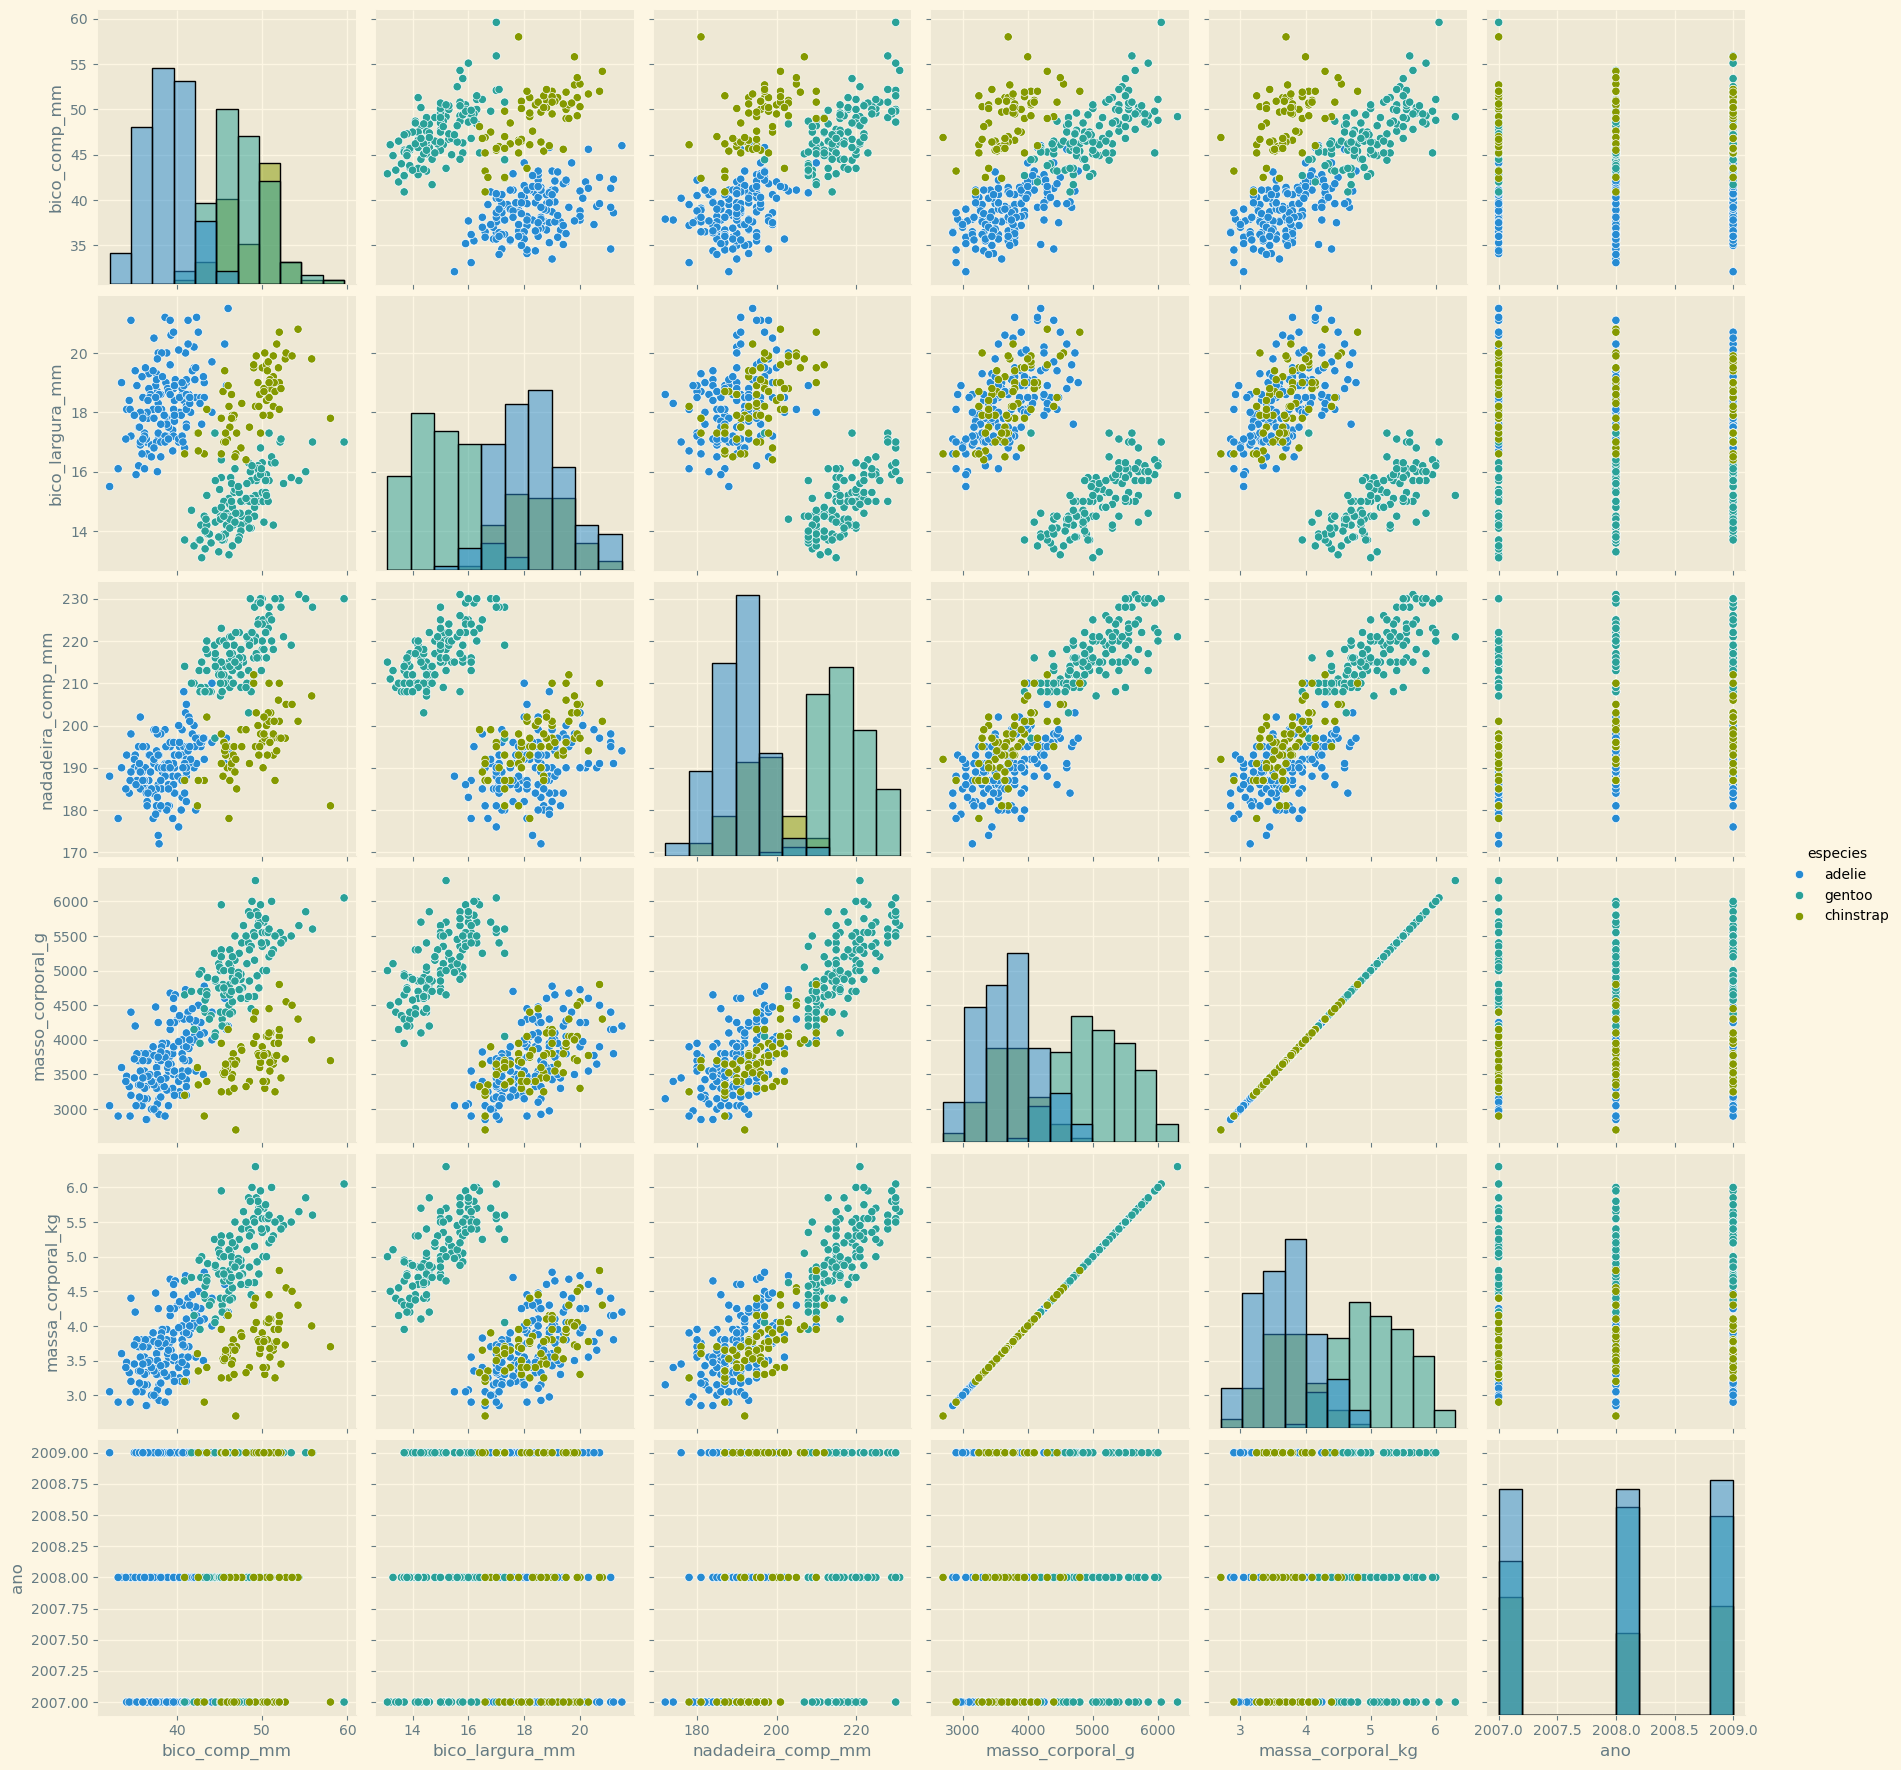

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('Solarize_Light2')

sns.pairplot(df, hue="especies", size=3, diag_kind="hist")
plt.show()

## 4. Machine Learning (Separação Treino/Teste)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Prepara as Features e o Target 
# Original slice era: X = valores[ :, 2 : 6 ] e y = valores[ :, 0 ]
valores = df.values
X = valores[:, 2:6] 
y = valores[:, 0]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.20, random_state=7
)

print(f"Treino: {X_treino.shape}, Teste: {X_teste.shape}")

Treino: (275, 4), Teste: (69, 4)


In [6]:
# Modelo Escolhido: Árvore de Decisão
model_dt = DecisionTreeClassifier()
model_dt.fit(X_treino, y_treino)

# Predição
teste_classificacao_dt = model_dt.predict(X_teste)
print("Acurácia modelo Decision Tree:", accuracy_score(y_teste, teste_classificacao_dt))
print("\n", classification_report(y_teste, teste_classificacao_dt))

Acurácia modelo Decision Tree: 0.9130434782608695

               precision    recall  f1-score   support

      adelie       1.00      0.83      0.91        30
   chinstrap       0.75      1.00      0.86        15
      gentoo       0.96      0.96      0.96        24

    accuracy                           0.91        69
   macro avg       0.90      0.93      0.91        69
weighted avg       0.93      0.91      0.91        69



## 5. Salvar Modelo: Fazendo Upload de volta ao MinIO (`warehouse`)

In [7]:
import pickle

# Em vez de salvar no Google Drive, salvamos localmente,
# Ou podemos fazer upload do modelo treinado de volta para o MinIO! (Model Registry simples)

filename = "decision_tree_penguins.pickle"
pickle.dump(model_dt, open(filename, "wb"))

print(f"Modelo salvo localmente como {filename}")
print("Efetuando upload do artefato pro MinIO (warehouse)...")

# Fazendo o upload pro Data Warehouse/Model Registry
try:
    s3_client.upload_file(filename, 'warehouse', f'models/v1/{filename}')
    print("Modelo salvo no Data Lake com sucesso (Bucket: warehouse) 🚀!")
except Exception as e:
    print(f"Erro ao salvar arquivo no S3/MinIO: {e}")

Modelo salvo localmente como decision_tree_penguins.pickle
Efetuando upload do artefato pro MinIO (warehouse)...
Modelo salvo no Data Lake com sucesso (Bucket: warehouse) 🚀!
